In [1]:
# =========================
# 🔥 BEST IMAGE ENHANCEMENT
# =========================
import cv2
import numpy as np
from PIL import Image

def enhance_image(img):
    img = np.array(img)

    # Denoise
    img = cv2.bilateralFilter(img, 9, 75, 75)

    # LAB color space
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    # Sharpen
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    img = cv2.filter2D(img, -1, kernel)

    return Image.fromarray(img)

In [2]:
import numpy as np
import torch

In [3]:
# =========================
# 🌿 LEAF SEGMENTATION
# =========================
def segment_leaf(img):
    img = np.array(img)

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    lower = np.array([25, 40, 40])
    upper = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)
    result = cv2.bitwise_and(img, img, mask=mask)

    return Image.fromarray(result)

In [4]:
# =========================
# EXPERIMENT FUNCTIONS
# =========================
import cv2
import numpy as np
from PIL import Image

# RGB (no change)
def identity(img):
    return img

# Grayscale
def to_grayscale(img):
    img = np.array(img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(gray)

# Enhancement
def enhance_image(img):
    img = np.array(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(img)

# Experiment modes
EXPERIMENTS = {
    "RGB": identity,
    "GRAYSCALE": to_grayscale,
    "ENHANCED": enhance_image
}

In [5]:

import cv2
from PIL import Image

def enhance_image(img):
    img = np.array(img)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.equalizeHist(l)
    lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(img)

def segment_leaf(img):
    img = np.array(img)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    lower = np.array([25, 40, 40])
    upper = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)
    result = cv2.bitwise_and(img, img, mask=mask)

    return Image.fromarray(result)

In [6]:
import os, sys, platform, subprocess, textwrap, json, time
from pathlib import Path

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Executable:", sys.executable)

def _run(cmd):
    try:
        out = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, text=True)
        return out.strip()
    except Exception as e:
        return f"[command failed] {cmd}\n{e}"

print("\n--- nvidia-smi (if available) ---")
print(_run("nvidia-smi"))

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Executable: /usr/bin/python3

--- nvidia-smi (if available) ---
Thu Apr  9 10:25:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  1536

In [7]:
# =========================
# B. Install & Imports
# - Install ONLY missing packages
# =========================
import sys, subprocess
import importlib.util

def ensure_pkg(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pip_name])
    else:
        print(f"Package OK: {import_name}")

# Don't auto-reinstall torch/torchvision
ensure_pkg("timm", "timm")
ensure_pkg("sklearn", "scikit-learn")
ensure_pkg("tqdm", "tqdm")
ensure_pkg("matplotlib", "matplotlib")
ensure_pkg("PIL", "Pillow")
ensure_pkg("tensorboard", "tensorboard")

import numpy as np
import torch
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import timm
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print("\n--- Versions ---")
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("timm:", timm.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    dev = torch.device("cuda")
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    total_vram_gb = props.total_memory / (1024**3)
    print(f"Total VRAM: {total_vram_gb:.2f} GB")
    print(f"VRAM allocated: {torch.cuda.memory_allocated(0)/ (1024**3):.2f} GB")
    print(f"VRAM reserved:  {torch.cuda.memory_reserved(0)/ (1024**3):.2f} GB")
    print("cuDNN enabled:", torch.backends.cudnn.enabled)
    print("cuDNN benchmark:", torch.backends.cudnn.benchmark)
else:
    print("\n⚠️ CUDA not available. Common LOCAL runtime causes:")
    print("- Installed CPU-only torch build (need CUDA build matching your driver/toolkit).")
    print("- NVIDIA driver not installed / outdated.")
    print("- CUDA toolkit mismatch vs your installed torch wheel.")
    print("- Running in an environment without GPU access.")
    print("Proceeding in CPU mode safely.")

Package OK: timm
Package OK: sklearn
Package OK: tqdm
Package OK: matplotlib
Package OK: PIL
Package OK: tensorboard

--- Versions ---
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
timm: 1.0.25
CUDA available: True
GPU: Tesla T4
Total VRAM: 14.56 GB
VRAM allocated: 0.00 GB
VRAM reserved:  0.00 GB
cuDNN enabled: True
cuDNN benchmark: False


In [8]:
# =========================
# C. Reproducibility + Config (ANDROID FINAL - offline optimized)
# Notes:
# - img_size=224 is the best default for mobile (speed/accuracy tradeoff).
# - We'll export ONNX and also generate an INT8 quantized ONNX for the Android app.
# =========================
import random
import numpy as np
import torch
from pathlib import Path

def seed_everything(seed=42, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

CONFIG = {
    "seed": 42,
    "deterministic": False,

    # FINAL APP / Android-friendly defaults
    "img_size": 224,
    "batch_size": 32,
    "epochs": 30,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "num_workers": 2,
    "train_val_split": 0.8,
    "output_dir": "./outputs_mobilenetv4_android_final",

    # MobileNetV4 (balanced for Android). INT8 export will be used in the app.
    "model_name": "mobilenetv4_conv_medium",

    # training stability
    "use_amp": True,
    "use_compile": False,   # keep off for stability
    "grad_clip": 1.0,
    "label_smoothing": 0.05,
    "early_stop_patience": 8,
    "best_metric": "macro_f1",
    "use_random_erasing": True,
    "tta_hflip_eval": False,

    # Export + Android optimization
    "export_opset": 17,
    "export_make_int8": True,
    "int8_calib_batches": 200,
    "benchmark_warmup": 20,
    "benchmark_runs": 200,
    "ort_prefer_int8": True,
}

seed_everything(CONFIG["seed"], CONFIG["deterministic"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["device"] = str(device)
print("Device:", device)

# TF32 (speed on Ampere+; harmless if unsupported)
if torch.cuda.is_available():
    try:
        torch.backends.fp32_precision = "tf32"
        torch.backends.cuda.matmul.fp32_precision = "tf32"
        torch.backends.cudnn.fp32_precision = "tf32"
        torch.backends.cudnn.conv.fp32_precision = "tf32"
    except Exception as e:
        print("TF32 new API not available in this torch build:", repr(e))

Path(CONFIG["output_dir"]).mkdir(parents=True, exist_ok=True)
print("Output dir:", Path(CONFIG["output_dir"]).resolve())

Device: cuda
Output dir: /kaggle/working/outputs_mobilenetv4_android_final


In [9]:
# =========================
# D1. Use Kaggle dataset directly + detect structure
# =========================
from pathlib import Path

# Option A: set the dataset folder manually
DATASET_DIR = Path("/kaggle/input/datasets/ashishmotwani/tomato")
# Example:
# DATASET_DIR = Path("/kaggle/input/tomato")

# Option B: auto-pick if exactly one dataset folder exists in /kaggle/input
input_root = Path("/kaggle/input")
available_roots = sorted([p for p in input_root.iterdir() if p.is_dir()]) if input_root.exists() else []

print("Available dataset roots under /kaggle/input:")
for p in available_roots:
    print(" -", p)

if DATASET_DIR is None:
    if len(available_roots) == 1:
        DATASET_DIR = available_roots[0]
        print("\nAuto-selected DATASET_DIR:", DATASET_DIR)
    else:
        raise ValueError(
            "Set DATASET_DIR manually because multiple dataset folders were found under /kaggle/input."
        )
else:
    DATASET_DIR = Path(DATASET_DIR)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f"Dataset path not found: {DATASET_DIR}")

def is_image_file(p: Path):
    return p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def count_images_in_dir(p: Path):
    if not p.exists():
        return 0
    return sum(1 for f in p.rglob("*") if f.is_file() and is_image_file(f))

def has_class_subdirs(p: Path):
    if not p.exists() or not p.is_dir():
        return False
    subs = [d for d in p.iterdir() if d.is_dir() and not d.name.startswith(".")]
    if len(subs) < 2:
        return False
    for d in subs[:10]:
        if count_images_in_dir(d) > 0:
            return True
    return False

def detect_structure_and_root(base_dir: Path):
    """
    Returns a dict:
    {
      'root': Path,
      'split_type': 'folders' or 'single_root',
      'train_dir': Path or None,
      'val_dir': Path or None,
      'test_dir': Path or None,
    }
    """
    candidates = [base_dir] + [p for p in base_dir.iterdir() if p.is_dir()]
    for p in base_dir.rglob("*"):
        if p.is_dir():
            candidates.append(p)

    split_names = {
        "train": ["train", "training"],
        "val": ["val", "valid", "validation"],
        "test": ["test", "testing"]
    }

    # prefer explicit split folders
    for c in candidates:
        found_train = next((c / name for name in split_names["train"] if (c / name).exists()), None)
        found_val   = next((c / name for name in split_names["val"] if (c / name).exists()), None)
        found_test  = next((c / name for name in split_names["test"] if (c / name).exists()), None)

        if found_train and found_val and has_class_subdirs(found_train) and has_class_subdirs(found_val):
            return {
                "root": c,
                "split_type": "folders",
                "train_dir": found_train,
                "val_dir": found_val,
                "test_dir": found_test if found_test and has_class_subdirs(found_test) else None
            }

    # otherwise find ImageFolder root: root/<class>/*.jpg
    best_score = -1
    best_root = None
    for c in candidates:
        if has_class_subdirs(c):
            img_count = count_images_in_dir(c)
            score = img_count
            if any((c / name).exists() for names in split_names.values() for name in names):
                score -= 1000
            if score > best_score:
                best_score = score
                best_root = c

    if best_root is None:
        raise RuntimeError("Could not detect ImageFolder root. Please check dataset structure.")

    return {
        "root": best_root,
        "split_type": "single_root",
        "train_dir": None,
        "val_dir": None,
        "test_dir": None
    }

info = detect_structure_and_root(DATASET_DIR)

print("\n--- Detected dataset structure ---")
for k, v in info.items():
    print(f"{k}: {v}")

ROOT = info["root"]
print("\nROOT =", ROOT)


Available dataset roots under /kaggle/input:
 - /kaggle/input/datasets

--- Detected dataset structure ---
root: /kaggle/input/datasets/ashishmotwani/tomato
split_type: folders
train_dir: /kaggle/input/datasets/ashishmotwani/tomato/train
val_dir: /kaggle/input/datasets/ashishmotwani/tomato/valid
test_dir: None

ROOT = /kaggle/input/datasets/ashishmotwani/tomato


In [10]:
# =========================
# D2. Build datasets + summary
# =========================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Accuracy-oriented but not overly destructive for leaf disease details
train_tfms = transforms.Compose([
    transforms.Lambda(lambda img: enhance_image(img)),
    transforms.Lambda(lambda img: segment_leaf(img)),
    transforms.RandomResizedCrop(CONFIG["img_size"], scale=(0.80, 1.0)),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

if CONFIG["use_random_erasing"]:
    train_tfms = transforms.Compose(list(train_tfms.transforms) + [
        transforms.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.3), value="random")
    ])

val_tfms = transforms.Compose([
    transforms.Lambda(lambda img: enhance_image(img)),
    transforms.Lambda(lambda img: segment_leaf(img)),
    transforms.Resize(int(CONFIG["img_size"] * 1.14)),
    transforms.CenterCrop(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def build_datasets(info):
    if info["split_type"] == "folders":
        train_ds = ImageFolder(info["train_dir"], transform=train_tfms)
        val_ds   = ImageFolder(info["val_dir"], transform=val_tfms)
        test_ds  = ImageFolder(info["test_dir"], transform=val_tfms) if info["test_dir"] else None
        class_names = train_ds.classes
        return train_ds, val_ds, test_ds, class_names

    # single_root => stratified split
    full_ds = ImageFolder(info["root"], transform=None)
    class_names = full_ds.classes
    y = [full_ds.targets[i] for i in range(len(full_ds))]
    idx = np.arange(len(full_ds))

    train_idx, val_idx = train_test_split(
        idx,
        train_size=CONFIG["train_val_split"],
        random_state=CONFIG["seed"],
        shuffle=True,
        stratify=y
    )

    train_ds = ImageFolder(info["root"], transform=train_tfms)
    val_ds   = ImageFolder(info["root"], transform=val_tfms)

    train_ds = Subset(train_ds, train_idx.tolist())
    val_ds   = Subset(val_ds, val_idx.tolist())

    return train_ds, val_ds, None, class_names

train_ds, val_ds, test_ds, class_names = build_datasets(info)

def dataset_counts(ds):
    if ds is None:
        return {}
    if isinstance(ds, Subset):
        targets = [ds.dataset.targets[i] for i in ds.indices]
    else:
        targets = ds.targets
    counts = {}
    for t in targets:
        counts[t] = counts.get(t, 0) + 1
    return {class_names[k]: v for k, v in sorted(counts.items(), key=lambda x: x[0])}

print("\n--- Summary ---")
print("Detected root:", ROOT.resolve())
print("Num classes:", len(class_names))
print("Classes:", class_names)
print("\nTrain counts:", dataset_counts(train_ds))
print("Val counts:  ", dataset_counts(val_ds))
if test_ds:
    print("Test counts: ", dataset_counts(test_ds))

def sample_paths(ds, n=3):
    paths = []
    if isinstance(ds, Subset):
        base = ds.dataset.samples
        for i in ds.indices[:n]:
            paths.append(base[i][0])
    else:
        for i in range(min(n, len(ds.samples))):
            paths.append(ds.samples[i][0])
    return paths

print("\nSample train paths:", sample_paths(train_ds, 3))
print("Sample val paths:  ", sample_paths(val_ds, 3))
if test_ds:
    print("Sample test paths: ", sample_paths(test_ds, 3))


--- Summary ---
Detected root: /kaggle/input/datasets/ashishmotwani/tomato
Num classes: 11
Classes: ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']

Train counts: {'Bacterial_spot': 2826, 'Early_blight': 2455, 'Late_blight': 3113, 'Leaf_Mold': 2754, 'Septoria_leaf_spot': 2882, 'Spider_mites Two-spotted_spider_mite': 1747, 'Target_Spot': 1827, 'Tomato_Yellow_Leaf_Curl_Virus': 2039, 'Tomato_mosaic_virus': 2153, 'healthy': 3051, 'powdery_mildew': 1004}
Val counts:   {'Bacterial_spot': 732, 'Early_blight': 643, 'Late_blight': 792, 'Leaf_Mold': 739, 'Septoria_leaf_spot': 746, 'Spider_mites Two-spotted_spider_mite': 435, 'Target_Spot': 457, 'Tomato_Yellow_Leaf_Curl_Virus': 498, 'Tomato_mosaic_virus': 584, 'healthy': 805, 'powdery_mildew': 252}

Sample train paths: ['/kaggle/input/datasets/ashishmotwani/tomato/train/B

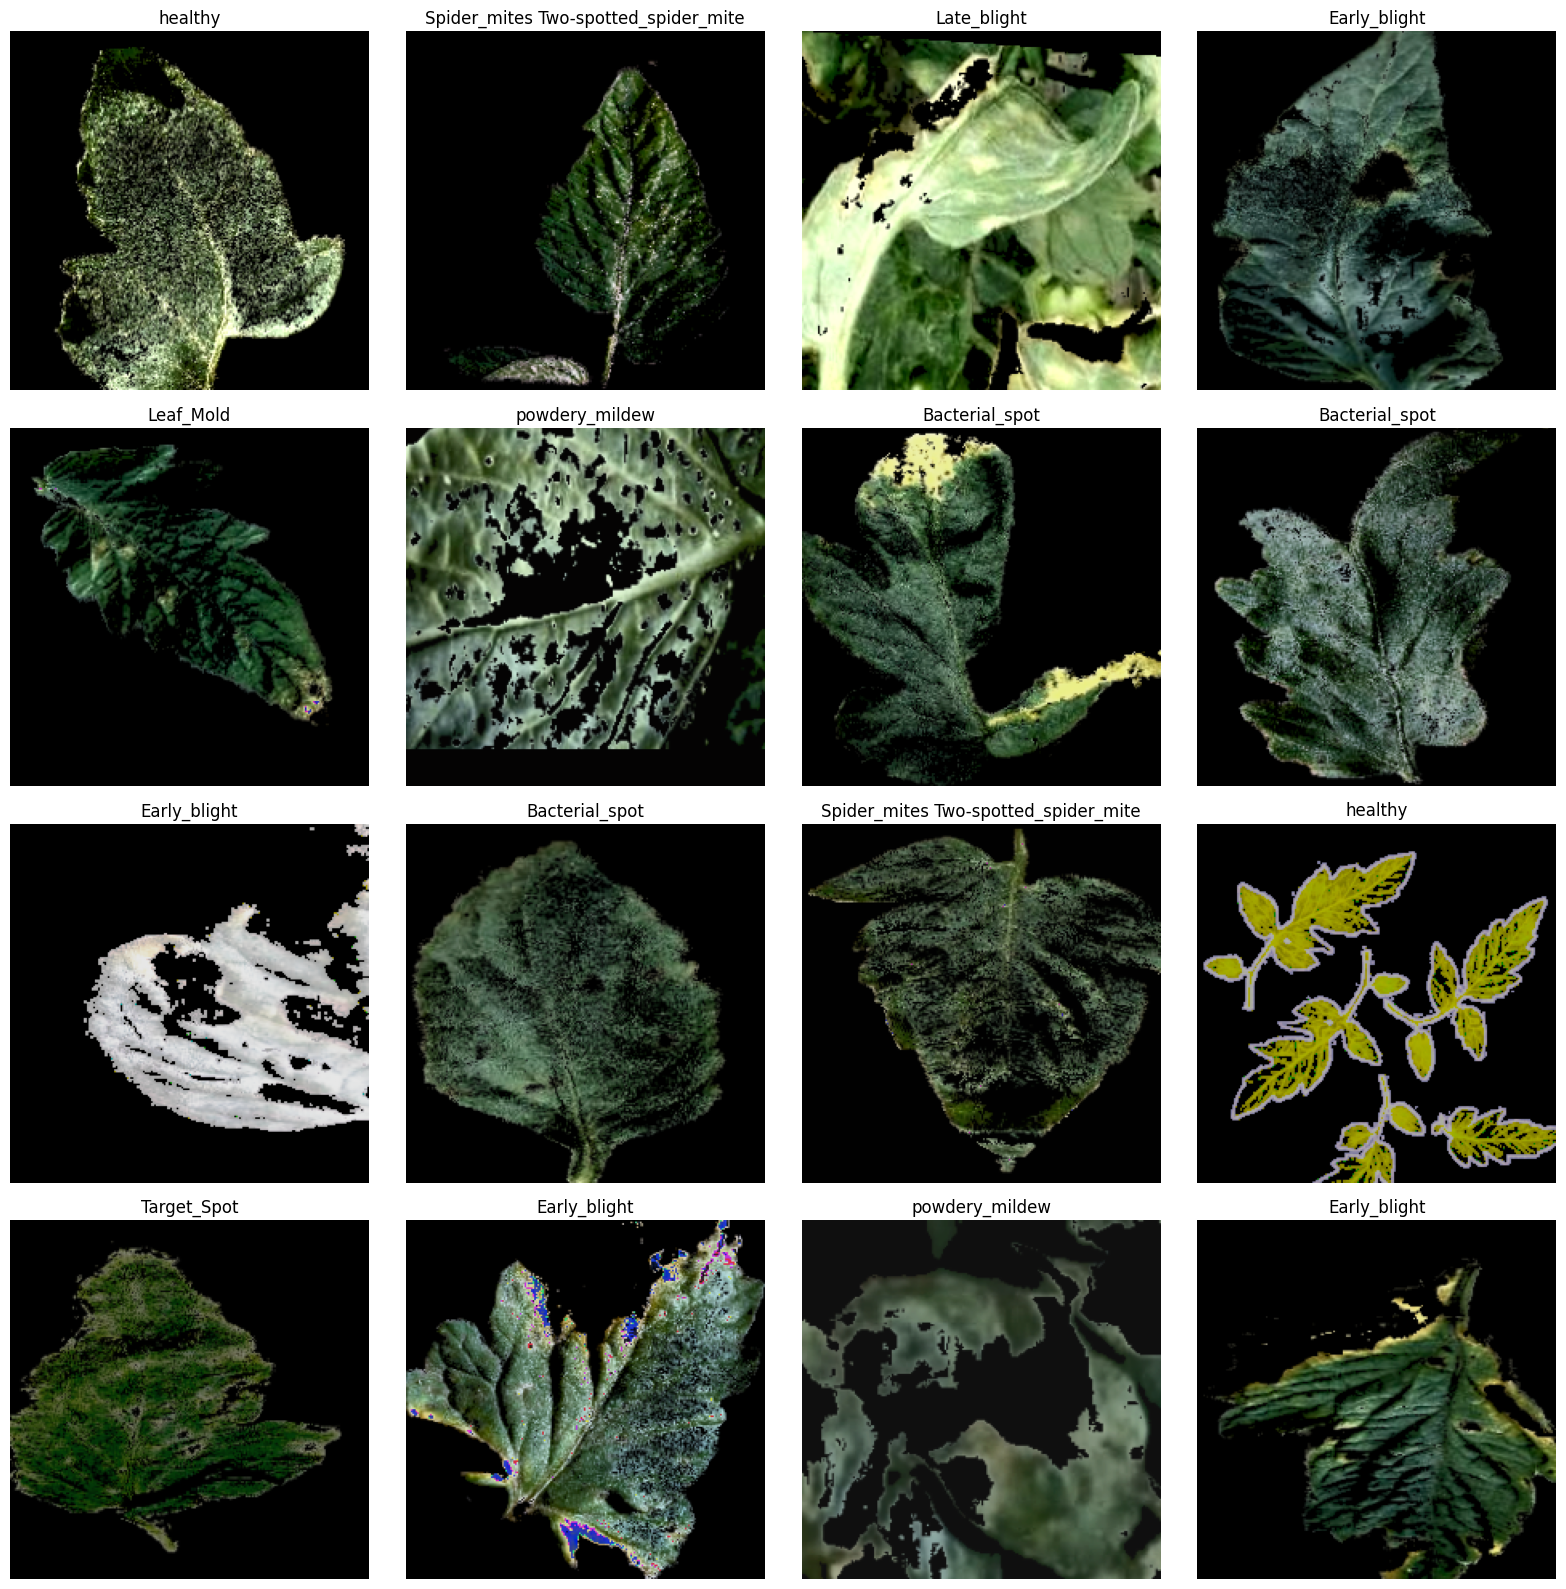

In [11]:
# =========================
# D3. DataLoaders + visualization
# =========================
pin = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=pin,
    persistent_workers=(CONFIG["num_workers"] > 0),
    prefetch_factor=2 if CONFIG["num_workers"] > 0 else None,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=pin,
    persistent_workers=(CONFIG["num_workers"] > 0),
    prefetch_factor=2 if CONFIG["num_workers"] > 0 else None,
    drop_last=False
)

test_loader = None
if test_ds is not None:
    test_loader = DataLoader(
        test_ds,
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        num_workers=CONFIG["num_workers"],
        pin_memory=pin,
        persistent_workers=(CONFIG["num_workers"] > 0),
        prefetch_factor=2 if CONFIG["num_workers"] > 0 else None,
        drop_last=False
    )

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def show_grid(loader, n=16):
    xb, yb = next(iter(loader))
    xb = xb[:n].cpu()
    yb = yb[:n].cpu()

    xb = xb * std + mean
    xb = xb.clamp(0, 1)

    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(np.transpose(xb[i].numpy(), (1, 2, 0)))
        plt.title(class_names[yb[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_grid(train_loader, n=16)


In [12]:
# =========================
# E. Model: MobileNetV4 via timm
# =========================

mobilenetv4_models = sorted([m for m in timm.list_models(pretrained=False) if "mobilenetv4" in m.lower()])
print("Available timm models containing 'mobilenetv4':")
for m in mobilenetv4_models:
    print(" -", m)

if len(mobilenetv4_models) == 0:
    raise RuntimeError("No MobileNetV4 model found in your installed timm version. Try upgrading timm.")

if CONFIG["model_name"] not in mobilenetv4_models:
    raise ValueError(
        f"CONFIG['model_name']={CONFIG['model_name']} not found in timm list. "
        f"Choose one of: {mobilenetv4_models}"
    )

print("\nSelected model:", CONFIG["model_name"])
num_classes = len(class_names)

try:
    model = timm.create_model(CONFIG["model_name"], pretrained=True, num_classes=num_classes)
    print("Loaded pretrained ImageNet weights.")
except Exception:
    print("Pretrained weights not available for this model; using random init.")
    model = timm.create_model(CONFIG["model_name"], pretrained=False, num_classes=num_classes)

model = model.to(device)

use_channels_last = True
if use_channels_last and device.type == "cuda":
    model = model.to(memory_format=torch.channels_last)
    print("Using channels_last memory format.")

compiled = False
if CONFIG.get("use_compile", False) and hasattr(torch, "compile"):
    try:
        model = torch.compile(model)
        compiled = True
        print("torch.compile enabled.")
    except Exception as e:
        print("torch.compile failed; continuing without it:", repr(e))
else:
    print("torch.compile disabled for stability.")

def imbalance_ratio(counts_dict):
    if not counts_dict:
        return 1.0
    vals = np.array(list(counts_dict.values()), dtype=float)
    return float(vals.max() / max(vals.min(), 1.0))

train_counts = dataset_counts(train_ds)
imb = imbalance_ratio(train_counts)
print("Imbalance ratio (max/min):", imb)

criterion = nn.CrossEntropyLoss(label_smoothing=CONFIG["label_smoothing"])
use_class_weights = imb >= 2.0
if use_class_weights:
    freq = np.array([train_counts.get(c, 1) for c in class_names], dtype=float)
    w = (1.0 / freq)
    w = w / w.sum() * len(w)
    class_weights = torch.tensor(w, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CONFIG["label_smoothing"])
    print("Class weights enabled.")
else:
    print("Class weights not used.")

optimizer = optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

total_steps = CONFIG["epochs"] * len(train_loader)
warmup_steps = int(0.05 * total_steps)

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

use_amp = (CONFIG["use_amp"] and device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print("AMP enabled:", use_amp)

Available timm models containing 'mobilenetv4':
 - mobilenetv4_conv_aa_large
 - mobilenetv4_conv_aa_medium
 - mobilenetv4_conv_blur_medium
 - mobilenetv4_conv_large
 - mobilenetv4_conv_medium
 - mobilenetv4_conv_small
 - mobilenetv4_conv_small_035
 - mobilenetv4_conv_small_050
 - mobilenetv4_hybrid_large
 - mobilenetv4_hybrid_large_075
 - mobilenetv4_hybrid_medium
 - mobilenetv4_hybrid_medium_075

Selected model: mobilenetv4_conv_medium


model.safetensors:   0%|          | 0.00/39.2M [00:00<?, ?B/s]

Loaded pretrained ImageNet weights.
Using channels_last memory format.
torch.compile disabled for stability.
Imbalance ratio (max/min): 3.100597609561753
Class weights enabled.
AMP enabled: True


In [13]:
# =========================
# F1. TensorBoard logging
# =========================
from torch.utils.tensorboard import SummaryWriter

run_name = f"{CONFIG['model_name']}_img{CONFIG['img_size']}_bs{CONFIG['batch_size']}_seed{CONFIG['seed']}"
tb_dir = Path(CONFIG["output_dir"]) / "runs" / run_name
writer = SummaryWriter(log_dir=str(tb_dir))
print("TensorBoard log dir:", tb_dir.resolve())

print("\nTo launch TensorBoard locally (in a terminal):")
print(f"  tensorboard --logdir \"{tb_dir.parent.resolve()}\" --port 6006")
print("Then open: http://localhost:6006")

2026-04-09 10:26:59.557505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775730419.774341      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775730419.835970      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775730420.362437      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775730420.362475      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775730420.362478      24 computation_placer.cc:177] computation placer alr

TensorBoard log dir: /kaggle/working/outputs_mobilenetv4_android_final/runs/mobilenetv4_conv_medium_img224_bs32_seed42

To launch TensorBoard locally (in a terminal):
  tensorboard --logdir "/kaggle/working/outputs_mobilenetv4_android_final/runs" --port 6006
Then open: http://localhost:6006


In [14]:
# =========================
# F2. Train / Eval loops
# =========================
# TTA FUNCTION
def predict_with_tta(model, x):
    out1 = model(x)
    x_flip = torch.flip(x, dims=[3])
    out2 = model(x_flip)
    return (out1 + out2) / 2
from dataclasses import dataclass

@dataclass
class BestState:
    best_metric: float = -1.0
    best_epoch: int = -1
    best_path: str = ""

best = BestState()
no_improve_epochs = 0

best_ckpt_path = str(Path(CONFIG["output_dir"]) / "best.pt")
last_ckpt_path = str(Path(CONFIG["output_dir"]) / "last.pt")

def accuracy_top1(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def save_state(epoch, path):
    to_save = model._orig_mod if hasattr(model, "_orig_mod") else model
    torch.save({
        "epoch": epoch,
        "model_state": to_save.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "config": CONFIG,
        "class_names": class_names,
    }, path)

def run_one_epoch(epoch, train=True):
    model.train(train)
    loader = train_loader if train else val_loader
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    all_preds = []
    all_targets = []

    pbar = tqdm(loader, desc=("Train" if train else "Val") + f" Epoch {epoch+1}/{CONFIG['epochs']}")
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if device.type == "cuda":
            xb = xb.contiguous(memory_format=torch.channels_last)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                logits = model(xb)
                loss = criterion(logits, yb)

            if train:
                scaler.scale(loss).backward()

                if CONFIG["grad_clip"] is not None and CONFIG["grad_clip"] > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])

                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

        acc = accuracy_top1(logits, yb)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.detach().cpu())
        all_targets.append(yb.detach().cpu())

        pbar.set_postfix(loss=total_loss / n_batches, acc=total_acc / n_batches, lr=optimizer.param_groups[0]["lr"])

    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    macro_f1 = f1_score(all_targets, all_preds, average="macro")

    return total_loss / n_batches, total_acc / n_batches, macro_f1, all_targets, all_preds

for epoch in range(CONFIG["epochs"]):
    train_loss, train_acc, train_f1, _, _ = run_one_epoch(epoch, train=True)
    val_loss, val_acc, val_f1, val_targets, val_preds = run_one_epoch(epoch, train=False)

    writer.add_scalar("loss/train", train_loss, epoch)
    writer.add_scalar("loss/val", val_loss, epoch)
    writer.add_scalar("acc/train", train_acc, epoch)
    writer.add_scalar("acc/val", val_acc, epoch)
    writer.add_scalar("f1/train_macro", train_f1, epoch)
    writer.add_scalar("f1/val_macro", val_f1, epoch)
    writer.add_scalar("lr", optimizer.param_groups[0]["lr"], epoch)

    save_state(epoch, last_ckpt_path)

    current_metric = val_f1 if CONFIG["best_metric"] == "macro_f1" else val_acc
    if current_metric > best.best_metric:
        best.best_metric = current_metric
        best.best_epoch = epoch
        best.best_path = best_ckpt_path
        save_state(epoch, best_ckpt_path)
        no_improve_epochs = 0
        print(
            f"\n✅ New best checkpoint: epoch={epoch} "
            f"val_acc={val_acc:.4f} val_f1={val_f1:.4f} best_metric={current_metric:.4f}"
        )
    else:
        no_improve_epochs += 1

    if no_improve_epochs >= CONFIG["early_stop_patience"]:
        print(
            f"\n⏹️ Early stopping: no {CONFIG['best_metric']} improvement for "
            f"{CONFIG['early_stop_patience']} epochs."
        )
        break

print(
    "\nBest epoch:", best.best_epoch,
    "| Best metric:", f"{best.best_metric:.4f}",
    "| Best path:", best.best_path
)
writer.close()

Train Epoch 1/30:   0%|          | 0/807 [00:00<?, ?it/s]

/tmp/ipykernel_24/900806790.py:74: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Val Epoch 1/30:   0%|          | 0/209 [00:00<?, ?it/s]


✅ New best checkpoint: epoch=0 val_acc=0.7210 val_f1=0.7173 best_metric=0.7173


Train Epoch 2/30:   0%|          | 0/807 [00:00<?, ?it/s]

...

Train Epoch 29/30:   0%|          | 0/807 [00:00<?, ?it/s]

Val Epoch 29/30:   0%|          | 0/209 [00:00<?, ?it/s]

Train Epoch 30/30:   0%|          | 0/807 [00:00<?, ?it/s]

Val Epoch 30/30:   0%|          | 0/209 [00:00<?, ?it/s]


⏹️ Early stopping: no macro_f1 improvement for 8 epochs.

Best epoch: 21 | Best metric: 0.9760 | Best path: outputs_mobilenetv4_android_final/best.pt


✅ Loaded checkpoint OK: mobilenetv4_conv_medium


Evaluating:   0%|          | 0/209 [00:00<?, ?it/s]


VAL top-1 acc: 0.9744
VAL macro F1 : 0.9760
TTA used     : False

Classification report:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.97      0.98      0.97       732
                        Early_blight       0.92      0.96      0.94       643
                         Late_blight       0.99      0.98      0.99       792
                           Leaf_Mold       0.98      0.99      0.99       739
                  Septoria_leaf_spot       0.97      0.96      0.97       746
Spider_mites Two-spotted_spider_mite       0.98      1.00      0.99       435
                         Target_Spot       0.99      0.98      0.98       457
       Tomato_Yellow_Leaf_Curl_Virus       0.99      1.00      0.99       498
                 Tomato_mosaic_virus       0.97      0.98      0.98       584
                             healthy       0.99      0.93      0.96       805
                      powdery_mildew       0.97    

,class,precision,recall,f1_score,support
7,Tomato_Yellow_Leaf_Curl_Virus,0.993988,0.995984,0.994985,498
5,Spider_mites Two-spotted_spider_mite,0.979730,1.000000,0.989761,435
3,Leaf_Mold,0.982597,0.993234,0.987887,739
2,Late_blight,0.992318,0.978535,0.985378,792
6,Target_Spot,0.988938,0.978118,0.983498,457
10,powdery_mildew,0.965385,0.996032,0.980469,252
8,Tomato_mosaic_virus,0.974490,0.981164,0.977816,584
0,Bacterial_spot,0.968877,0.978142,0.973487,732
4,Septoria_leaf_spot,0.971583,0.962466,0.967003,746
9,healthy,0.985488,0.927950,0.955854,805


Saved per-class CSV to: /kaggle/working/outputs_mobilenetv4_android_final/val_per_class_report.csv


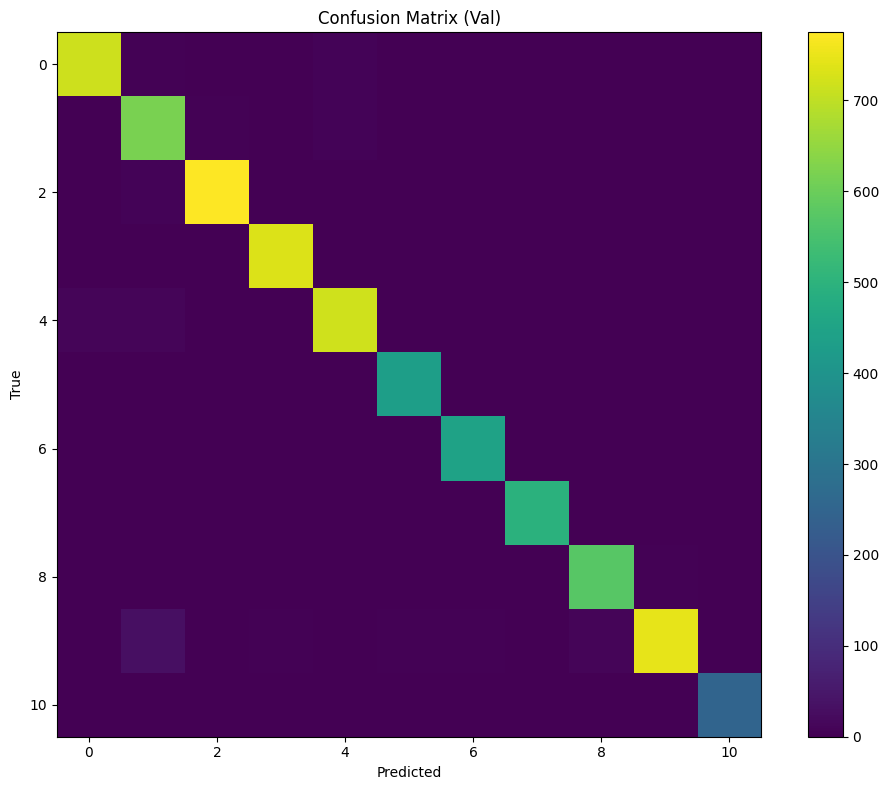

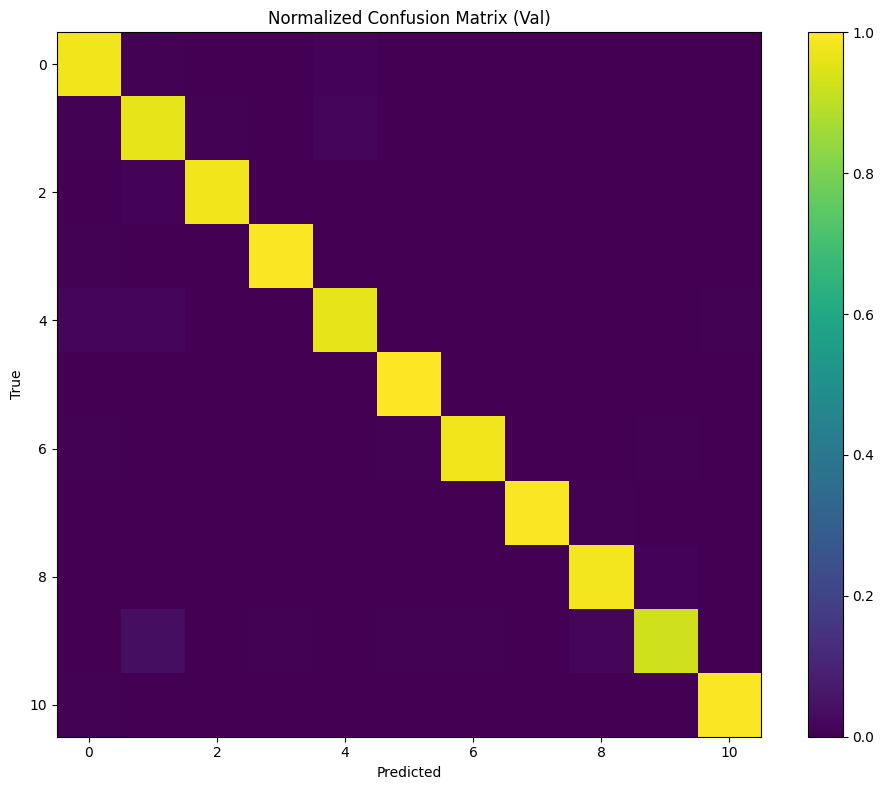


Top 10 misclassifications (True -> Pred):
  31 | healthy -> Early_blight
  11 | Septoria_leaf_spot -> Early_blight
  11 | healthy -> Tomato_mosaic_virus
  10 | Septoria_leaf_spot -> Bacterial_spot
   9 | Early_blight -> Septoria_leaf_spot
   8 | Late_blight -> Early_blight
   7 | Bacterial_spot -> Septoria_leaf_spot
   6 | healthy -> Spider_mites Two-spotted_spider_mite
   5 | Bacterial_spot -> Early_blight
   5 | Tomato_mosaic_virus -> healthy


In [15]:
# =========================
# F3. Final evaluation + per-class report + optional TTA
# =========================
import torch
import timm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support
)

ckpt = torch.load(best_ckpt_path, map_location=device, weights_only=False)

ckpt_cfg = ckpt.get("config", {})
model_name = ckpt_cfg.get("model_name", CONFIG.get("model_name"))
class_names = ckpt.get("class_names", class_names)

model_eval = timm.create_model(model_name, pretrained=False, num_classes=len(class_names)).to(device)
model_eval.eval()

state = ckpt["model_state"]

if any(k.startswith("_orig_mod.") for k in state.keys()):
    state = {k.replace("_orig_mod.", "", 1): v for k, v in state.items()}
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model_eval.load_state_dict(state, strict=True)
print("✅ Loaded checkpoint OK:", model_name)

if device.type == "cuda":
    model_eval = model_eval.to(memory_format=torch.channels_last)

@torch.no_grad()
def predict_loader(loader, use_tta=False):
    all_preds, all_targets, all_probs = [], [], []
    for xb, yb in tqdm(loader, desc="Evaluating"):
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if device.type == "cuda":
            xb = xb.contiguous(memory_format=torch.channels_last)

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            logits = model_eval(xb)
            probs = torch.softmax(logits, dim=1)

            if use_tta:
                xb_flip = torch.flip(xb, dims=[3])
                logits_flip = model_eval(xb_flip)
                probs_flip = torch.softmax(logits_flip, dim=1)
                probs = (probs + probs_flip) / 2.0

            preds = torch.argmax(probs, dim=1)

        all_preds.append(preds.cpu())
        all_targets.append(yb.cpu())
        all_probs.append(probs.cpu())

    return (
        torch.cat(all_targets).numpy(),
        torch.cat(all_preds).numpy(),
        torch.cat(all_probs).numpy()
    )

# ---------- VAL ----------
val_targets, val_preds, val_probs = predict_loader(val_loader, use_tta=CONFIG["tta_hflip_eval"])
val_acc = (val_targets == val_preds).mean()
val_f1 = f1_score(val_targets, val_preds, average="macro")

print(f"\nVAL top-1 acc: {val_acc:.4f}")
print(f"VAL macro F1 : {val_f1:.4f}")
print(f"TTA used     : {CONFIG['tta_hflip_eval']}\n")

print("Classification report:")
print(classification_report(val_targets, val_preds, target_names=class_names, zero_division=0))

prec, rec, f1, sup = precision_recall_fscore_support(
    val_targets,
    val_preds,
    labels=list(range(len(class_names))),
    zero_division=0
)

per_class_df = pd.DataFrame({
    "class": class_names,
    "precision": prec,
    "recall": rec,
    "f1_score": f1,
    "support": sup
}).sort_values("f1_score", ascending=False)

print("\nPer-class evaluation:")
display(per_class_df)

per_class_csv = Path(CONFIG["output_dir"]) / "val_per_class_report.csv"
per_class_df.to_csv(per_class_csv, index=False)
print("Saved per-class CSV to:", per_class_csv.resolve())

cm = confusion_matrix(val_targets, val_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_norm = cm.astype("float") / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm)
plt.title("Normalized Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if cm_offdiag[i, j] > 0:
            pairs.append((cm_offdiag[i, j], class_names[i], class_names[j]))
pairs.sort(reverse=True, key=lambda x: x[0])

print("\nTop 10 misclassifications (True -> Pred):")
for count, true_cls, pred_cls in pairs[:10]:
    print(f"{count:4d} | {true_cls} -> {pred_cls}")

# ---------- TEST ----------
if test_loader is not None:
    test_targets, test_preds, _ = predict_loader(test_loader, use_tta=CONFIG["tta_hflip_eval"])
    test_acc = (test_targets == test_preds).mean()
    test_f1 = f1_score(test_targets, test_preds, average="macro")

    print(f"\nTEST top-1 acc: {test_acc:.4f}")
    print(f"TEST macro F1 : {test_f1:.4f}\n")

    test_prec, test_rec, test_f1_each, test_sup = precision_recall_fscore_support(
        test_targets,
        test_preds,
        labels=list(range(len(class_names))),
        zero_division=0
    )

    test_per_class_df = pd.DataFrame({
        "class": class_names,
        "precision": test_prec,
        "recall": test_rec,
        "f1_score": test_f1_each,
        "support": test_sup
    }).sort_values("f1_score", ascending=False)

    print("Test per-class evaluation:")
    display(test_per_class_df)

    test_per_class_csv = Path(CONFIG["output_dir"]) / "test_per_class_report.csv"
    test_per_class_df.to_csv(test_per_class_csv, index=False)
    print("Saved test per-class CSV to:", test_per_class_csv.resolve())

Sampling images from: /kaggle/input/datasets/ashishmotwani/tomato/valid
Random image: /kaggle/input/datasets/ashishmotwani/tomato/valid/Bacterial_spot/BS_(381).jpg
Prediction : Bacterial_spot
Confidence : 0.9399


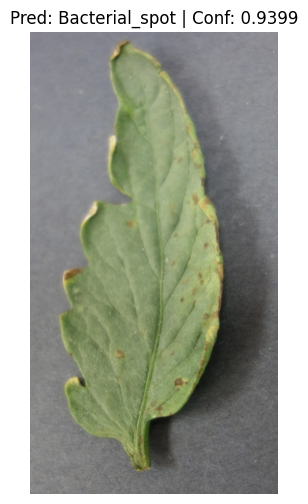

In [16]:
# =========================
# F4. Inference helper (random sample from detected dataset)
# =========================
from PIL import Image
from pathlib import Path
import random

# Prefer validation folder if it exists; otherwise sample from ROOT
if info.get("split_type") == "folders" and info.get("val_dir") is not None:
    SAMPLE_PATH = Path(info["val_dir"])
else:
    SAMPLE_PATH = Path(ROOT)

print("Sampling images from:", SAMPLE_PATH)

inference_tfm = transforms.Compose([
    transforms.Resize(int(CONFIG["img_size"] * 1.14)),
    transforms.CenterCrop(CONFIG["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

@torch.no_grad()
def predict_image(image_path: str):
    img = Image.open(image_path).convert("RGB")
    x = inference_tfm(img).unsqueeze(0).to(device)

    if device.type == "cuda":
        x = x.contiguous(memory_format=torch.channels_last)

    with torch.amp.autocast(device_type="cuda", enabled=use_amp):
        logits = model_eval(x)
        probs = torch.softmax(logits, dim=1).squeeze(0)

    conf, idx = torch.max(probs, dim=0)
    pred_class = ckpt["class_names"][idx.item()]
    return pred_class, float(conf.item())

def get_random_image_path():
    image_files = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
        image_files.extend(SAMPLE_PATH.rglob(ext))

    if len(image_files) == 0:
        raise ValueError(f"No images found in: {SAMPLE_PATH}")

    return str(random.choice(image_files))

random_img = get_random_image_path()
pred, prob = predict_image(random_img)

print("Random image:", random_img)
print("Prediction :", pred)
print("Confidence :", round(prob, 4))

img = Image.open(random_img).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Pred: {pred} | Conf: {prob:.4f}")
plt.axis("off")
plt.show()

In [17]:
 #=========================
# G1. Export model for Android deployment (recommended: ONNX + metadata)
# =========================
# Why this path:
# - ONNX Runtime provides an Android image-classification flow and a mobile runtime.
# - PyTorch Mobile/TorchScript mobile is deprecated; ExecuTorch is the newer PyTorch-native path.
# - For a straightforward notebook-to-Android flow, ONNX is the easiest export artifact here.

import sys, subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "onnx", "onnxscript", "onnxruntime"])
print("✅ Installed: onnx, onnxscript, onnxruntime")

from pathlib import Path
import json
import torch
import timm

EXPORT_DIR = Path(CONFIG["output_dir"]) / "android_export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Rebuild best model from checkpoint
ckpt = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)
ckpt_cfg = ckpt.get("config", {})
export_model_name = ckpt_cfg.get("model_name", CONFIG.get("model_name"))
export_class_names = ckpt.get("class_names", class_names)

model_export = timm.create_model(
    export_model_name,
    pretrained=False,
    num_classes=len(export_class_names)
).cpu().eval()

state = ckpt["model_state"]
if any(k.startswith("_orig_mod.") for k in state.keys()):
    state = {k.replace("_orig_mod.", "", 1): v for k, v in state.items()}
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model_export.load_state_dict(state, strict=True)

# Dummy input must match your inference input shape
dummy = torch.randn(1, 3, CONFIG["img_size"], CONFIG["img_size"], dtype=torch.float32)

onnx_path = EXPORT_DIR / f"{export_model_name}.onnx"
torch.onnx.export(
    model_export,
    dummy,
    onnx_path.as_posix(),
    input_names=["input"],
    output_names=["logits"],
    opset_version=CONFIG.get('export_opset', 17),
    do_constant_folding=True,
    dynamic_axes=None,   # fixed-size input is simpler and more stable for mobile
)

# Save labels + preprocessing metadata for Android app
meta = {
    "model_name": export_model_name,
    "input_size": [1, 3, CONFIG["img_size"], CONFIG["img_size"]],
    "class_names": export_class_names,
    "mean": list(IMAGENET_MEAN),
    "std": list(IMAGENET_STD),
    "resize": int(CONFIG["img_size"] * 1.14),
    "center_crop": CONFIG["img_size"],
    "input_tensor_name": "input",
    "output_tensor_name": "logits",
    "notes": "Android app must use the same resize/crop/normalize pipeline as training inference.",
    "onnx_fp32": f"{export_model_name}.onnx",
    "onnx_int8": None,
    "preferred_onnx": f"{export_model_name}.onnx"
}
meta_path = EXPORT_DIR / "metadata.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

# Also save labels as plain text for easier Android loading
labels_path = EXPORT_DIR / "labels.txt"
with open(labels_path, "w", encoding="utf-8") as f:
    for c in export_class_names:
        f.write(c + "\n")

print("✅ Android export complete")
print("ONNX      :", onnx_path.resolve())
print("Metadata  :", meta_path.resolve())
print("Labels    :", labels_path.resolve())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: onnx
    Found existing installation: onnx 1.20.1
    Uninstalling onnx-1.20.1:
      Successfully uninstalled onnx-1.20.1
✅ Installed: onnx, onnxscript, onnxruntime


W0409 12:33:08.697000 24 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0409 12:33:09.424000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0409 12:33:09.426000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, ali

[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Translate the graph into ONNX... ✅
Applied 154 of general pattern rewrite rules.
✅ Android export complete
ONNX      : /kaggle/working/outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium.onnx
Metadata  : /kaggle/working/outputs_mobilenetv4_android_final/android_export/metadata.json
Labels    : /kaggle/working/outputs_mobilenetv4_android_final/android_export/labels.txt


In [18]:
# =========================
# G2. Verify exported ONNX locally (optional but recommended)
# - Simplify ONNX
# - Smoke test with ONNX Runtime
# =========================
import importlib, subprocess, sys, json
from pathlib import Path

def ensure_pkg(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        print(f"✅ {pkg} already installed")
        return
    except Exception:
        pass
    print(f"Installing {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pkg])

ensure_pkg("onnx")
ensure_pkg("onnxruntime")
ensure_pkg("onnxsim")

import onnx
import onnxruntime as ort
import numpy as np
from onnxsim import simplify

EXPORT_DIR = Path(CONFIG["output_dir"]) / "android_export"
meta = json.load(open(EXPORT_DIR / "metadata.json", "r", encoding="utf-8"))
onnx_path = EXPORT_DIR / meta.get("onnx_fp32", f"{meta['model_name']}.onnx")

# Simplify (in-place)
model_onnx = onnx.load(onnx_path.as_posix())
model_simplified, check = simplify(model_onnx)
assert check, "ONNX simplification failed"
onnx.save(model_simplified, onnx_path.as_posix())
print("✅ Simplified ONNX:", onnx_path.resolve())

# Quick runtime test
sess = ort.InferenceSession(onnx_path.as_posix(), providers=["CPUExecutionProvider"])
inp_name = sess.get_inputs()[0].name
out_name = sess.get_outputs()[0].name

x = np.random.randn(1, 3, CONFIG["img_size"], CONFIG["img_size"]).astype(np.float32)
y = sess.run([out_name], {inp_name: x})[0]
print("✅ ONNX Runtime OK")
print("Input name :", inp_name)
print("Output name:", out_name)
print("Output shape:", y.shape)

✅ onnx already installed
✅ onnxruntime already installed
Installing onnxsim ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 71.5 MB/s eta 0:00:00
✅ Simplified ONNX: /kaggle/working/outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium.onnx
✅ ONNX Runtime OK
Input name : input
Output name: logits
Output shape: (1, 11)


In [19]:
# =========================
# G3. INT8 Quantization for Android (recommended)
# - Generates <model>_int8.onnx and updates metadata.json
# =========================
import json, sys, subprocess
from pathlib import Path

# Ensure ORT quantization tools are available
try:
    import onnxruntime as ort
    from onnxruntime.quantization import (
        quantize_static, quantize_dynamic,
        CalibrationDataReader,
        QuantType, QuantFormat
    )
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "onnxruntime"])
    import onnxruntime as ort
    from onnxruntime.quantization import (
        quantize_static, quantize_dynamic,
        CalibrationDataReader,
        QuantType, QuantFormat
    )

import numpy as np
from torch.utils.data import DataLoader

EXPORT_DIR = Path(CONFIG["output_dir"]) / "android_export"
meta_path = EXPORT_DIR / "metadata.json"
meta = json.load(open(meta_path, "r", encoding="utf-8"))

onnx_fp32 = EXPORT_DIR / meta.get("onnx_fp32", f"{meta['model_name']}.onnx")
onnx_int8 = EXPORT_DIR / f"{meta['model_name']}_int8.onnx"

# Calibration loader (uses the same preprocessing as inference)
calib_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

class CalibReader(CalibrationDataReader):
    def __init__(self, loader, input_name, num_batches=200):
        self.loader = loader
        self.input_name = input_name
        self.num_batches = int(num_batches)
        self.iterator = iter(loader)
        self.i = 0

    def get_next(self):
        if self.i >= self.num_batches:
            return None
        try:
            xb, _ = next(self.iterator)
        except StopIteration:
            return None
        self.i += 1
        return {self.input_name: xb.numpy().astype(np.float32)}

# Determine input name from the FP32 model
sess = ort.InferenceSession(onnx_fp32.as_posix(), providers=["CPUExecutionProvider"])
inp_name = sess.get_inputs()[0].name

if CONFIG.get("export_make_int8", True):
    print("Quantizing:", onnx_fp32.name, "->", onnx_int8.name)
    try:
        calib_reader = CalibReader(calib_loader, inp_name, num_batches=CONFIG.get("int8_calib_batches", 200))
        quantize_static(
            model_input=onnx_fp32.as_posix(),
            model_output=onnx_int8.as_posix(),
            calibration_data_reader=calib_reader,
            quant_format=QuantFormat.QDQ,
            activation_type=QuantType.QInt8,
            weight_type=QuantType.QInt8,
            per_channel=True,
        )
        print("✅ INT8 (static) saved:", onnx_int8.resolve())
    except Exception as e:
        print("⚠️ Static INT8 failed, falling back to dynamic quantization:", repr(e))
        quantize_dynamic(
            model_input=onnx_fp32.as_posix(),
            model_output=onnx_int8.as_posix(),
            weight_type=QuantType.QInt8
        )
        print("✅ INT8 (dynamic) saved:", onnx_int8.resolve())
else:
    print("CONFIG['export_make_int8']=False, skipping INT8 export.")

# Update metadata.json so Android app can always pick the best file
meta["onnx_fp32"] = onnx_fp32.name
meta["onnx_int8"] = onnx_int8.name if onnx_int8.exists() else None
meta["preferred_onnx"] = (meta["onnx_int8"] if (meta["onnx_int8"] and CONFIG.get("ort_prefer_int8", True)) else meta["onnx_fp32"])

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

def _mb(p):
    return p.stat().st_size / (1024**2)

print("\n--- Export sizes ---")
print("FP32 (MB):", round(_mb(onnx_fp32), 2), "|", onnx_fp32.name)
if onnx_int8.exists():
    print("INT8 (MB):", round(_mb(onnx_int8), 2), "|", onnx_int8.name)
print("Preferred:", meta["preferred_onnx"])

Quantizing: mobilenetv4_conv_medium.onnx -> mobilenetv4_conv_medium_int8.onnx


✅ INT8 (static) saved: /kaggle/working/outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium_int8.onnx

--- Export sizes ---
FP32 (MB): 32.13 | mobilenetv4_conv_medium.onnx
INT8 (MB): 8.67 | mobilenetv4_conv_medium_int8.onnx
Preferred: mobilenetv4_conv_medium_int8.onnx


In [20]:
# =========================
# G4. Mobile-style benchmark (FP32 vs INT8) + quick accuracy check
# - Measures ONNX Runtime CPU latency on real preprocessed samples
# - Computes top-1 accuracy on a subset (sanity check)
# =========================
import time, json, os
from pathlib import Path
import numpy as np

import onnxruntime as ort
from torch.utils.data import DataLoader

EXPORT_DIR = Path(CONFIG["output_dir"]) / "android_export"
meta = json.load(open(EXPORT_DIR / "metadata.json", "r", encoding="utf-8"))

onnx_fp32 = EXPORT_DIR / meta["onnx_fp32"]
onnx_int8 = EXPORT_DIR / meta["onnx_int8"] if meta.get("onnx_int8") else None

def make_sess(path: Path):
    so = ort.SessionOptions()
    so.intra_op_num_threads = max(1, (os.cpu_count() or 2) // 2)
    so.inter_op_num_threads = 1
    return ort.InferenceSession(path.as_posix(), sess_options=so, providers=["CPUExecutionProvider"])

def eval_sess(sess, loader, max_batches=200):
    inp = sess.get_inputs()[0].name
    out = sess.get_outputs()[0].name
    correct = 0
    total = 0

    # warmup
    warm = int(CONFIG.get("benchmark_warmup", 20))
    it = iter(loader)
    for _ in range(warm):
        try:
            xb, _ = next(it)
        except StopIteration:
            break
        _ = sess.run([out], {inp: xb.numpy().astype(np.float32)})

    # timed runs + accuracy
    t0 = time.perf_counter()
    it = iter(loader)
    runs = int(CONFIG.get("benchmark_runs", 200))
    batches = min(runs, max_batches)
    for _ in range(batches):
        try:
            xb, yb = next(it)
        except StopIteration:
            break
        logits = sess.run([out], {inp: xb.numpy().astype(np.float32)})[0]
        pred = int(np.argmax(logits, axis=1)[0])
        y = int(yb.numpy()[0])
        correct += (pred == y)
        total += 1
    t1 = time.perf_counter()

    if total == 0:
        return None

    avg_ms = (t1 - t0) * 1000.0 / total
    acc = correct / total
    return {"avg_ms": avg_ms, "acc_subset": acc, "n": total}

bench_loader = DataLoader(val_ds, batch_size=1, shuffle=True, num_workers=0)

print("Benchmarking on CPU (this is the closest to Android CPU baseline)...")

sess_fp32 = make_sess(onnx_fp32)
r_fp32 = eval_sess(sess_fp32, bench_loader, max_batches=CONFIG.get("benchmark_runs", 200))
print("\nFP32:", onnx_fp32.name)
print(r_fp32)

if onnx_int8 and onnx_int8.exists():
    sess_int8 = make_sess(onnx_int8)
    r_int8 = eval_sess(sess_int8, bench_loader, max_batches=CONFIG.get("benchmark_runs", 200))
    print("\nINT8:", onnx_int8.name)
    print(r_int8)

    if r_fp32 and r_int8:
        speedup = r_fp32["avg_ms"] / max(r_int8["avg_ms"], 1e-9)
        print(f"\nEstimated speedup (FP32/INT8): {speedup:.2f}x")
        print("Preferred for Android:", meta.get("preferred_onnx"))
else:
    print("\nINT8 model not found. Run G3 first.")

Benchmarking on CPU (this is the closest to Android CPU baseline)...

FP32: mobilenetv4_conv_medium.onnx
{'avg_ms': 18.703021530000115, 'acc_subset': 0.985, 'n': 200}

INT8: mobilenetv4_conv_medium_int8.onnx
{'avg_ms': 21.070615625003484, 'acc_subset': 0.14, 'n': 200}

Estimated speedup (FP32/INT8): 0.89x
Preferred for Android: mobilenetv4_conv_medium_int8.onnx


In [21]:
# =========================
# G5. Optional: Convert preferred ONNX -> ORT format (often smaller + faster load on Android)
# =========================
import json, sys, subprocess
from pathlib import Path

EXPORT_DIR = Path(CONFIG["output_dir"]) / "android_export"
meta = json.load(open(EXPORT_DIR / "metadata.json", "r", encoding="utf-8"))
preferred = meta.get("preferred_onnx", meta.get("onnx_fp32"))

onnx_in = EXPORT_DIR / preferred
ort_out = EXPORT_DIR / (Path(preferred).stem + ".ort")

print("Preferred ONNX:", onnx_in.name)

# Try ORT conversion tool. If it isn't available, this cell will print guidance and continue.
try:
    import onnxruntime
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "onnxruntime"])

try:
    # CLI tool shipped with onnxruntime
    cmd = [sys.executable, "-m", "onnxruntime.tools.convert_onnx_models_to_ort",
           "--input", onnx_in.as_posix(),
           "--output", ort_out.as_posix()]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)
    print("✅ ORT model saved:", ort_out.resolve())
    meta["preferred_ort"] = ort_out.name
    with open(EXPORT_DIR / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)
except Exception as e:
    print("⚠️ ORT conversion tool not available in this environment.")
    print("Reason:", repr(e))
    print("You can skip this; Android can run the ONNX directly via ONNX Runtime Android.")

Preferred ONNX: mobilenetv4_conv_medium_int8.onnx
Running: /usr/bin/python3 -m onnxruntime.tools.convert_onnx_models_to_ort --input outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium_int8.onnx --output outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium_int8.ort


usage: convert_onnx_models_to_ort.py [-h] [--output_dir OUTPUT_DIR]
                                     [--optimization_style {Fixed,Runtime} [{Fixed,Runtime} ...]]
                                     [--enable_type_reduction]
                                     [--custom_op_library CUSTOM_OP_LIBRARY]
                                     [--save_optimized_onnx_model]
                                     [--allow_conversion_failures]
                                     [--target_platform {arm,amd64}]
                                     model_path_or_dir
convert_onnx_models_to_ort.py: error: unrecognized arguments: --input


⚠️ ORT conversion tool not available in this environment.
Reason: CalledProcessError(2, ['/usr/bin/python3', '-m', 'onnxruntime.tools.convert_onnx_models_to_ort', '--input', 'outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium_int8.onnx', '--output', 'outputs_mobilenetv4_android_final/android_export/mobilenetv4_conv_medium_int8.ort'])
You can skip this; Android can run the ONNX directly via ONNX Runtime Android.


In [22]:
# =========================
# G6. Android integration notes (FINAL)
# =========================
import json
from pathlib import Path

print(f"""
FINAL Android deployment artifacts are in:
  {Path(CONFIG['output_dir']).resolve() / 'android_export'}

Copy into your Android project (assets/):
- {Path(CONFIG['output_dir']) / 'android_export' / 'metadata.json'}
- {Path(CONFIG['output_dir']) / 'android_export' / 'labels.txt'}
- Preferred model file:
    {json.load(open(Path(CONFIG['output_dir']) / 'android_export' / 'metadata.json', 'r', encoding='utf-8')).get('preferred_onnx')}

Android preprocessing MUST match metadata.json:
- resize to int(img_size * 1.14)
- center crop to img_size
- RGB -> float32 tensor [1,3,H,W]
- normalize with ImageNet mean/std

Recommended runtime:
- ONNX Runtime Android (use NNAPI Execution Provider if your device supports it)

Tip:
- If G5 produced a .ort file, you can optionally ship that (often loads faster), but ONNX is already fine.
""")


FINAL Android deployment artifacts are in:
  /kaggle/working/outputs_mobilenetv4_android_final/android_export

Copy into your Android project (assets/):
- outputs_mobilenetv4_android_final/android_export/metadata.json
- outputs_mobilenetv4_android_final/android_export/labels.txt
- Preferred model file:
    mobilenetv4_conv_medium_int8.onnx

Android preprocessing MUST match metadata.json:
- resize to int(img_size * 1.14)
- center crop to img_size
- RGB -> float32 tensor [1,3,H,W]
- normalize with ImageNet mean/std

Recommended runtime:
- ONNX Runtime Android (use NNAPI Execution Provider if your device supports it)

Tip:
- If G5 produced a .ort file, you can optionally ship that (often loads faster), but ONNX is already fine.



In [23]:
# =========================
# STEP 3: MODEL COMPARISON
# =========================

import numpy as np
from sklearn.metrics import f1_score
import timm
import torch

extra_models = ["resnet50", "efficientnet_b0"]

results = {}

for name in extra_models:
    print(f"\n🔥 Testing {name}")

    model_test = timm.create_model(
        name,
        pretrained=True,
        num_classes=len(class_names)
    ).to(device)

    model_test.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            y = y.to(device)

            out = model_test(x)
            p = torch.argmax(out, dim=1)

            preds.extend(p.cpu().numpy())
            targets.extend(y.cpu().numpy())

    acc = np.mean(np.array(preds) == np.array(targets))
    f1 = f1_score(targets, preds, average="macro")

    results[name] = {"accuracy": acc, "f1": f1}

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

# =========================
# FINAL RESULTS
# =========================
print("\n===== FINAL COMPARISON =====")
for model_name, res in results.items():
    print(f"{model_name}: Acc={res['accuracy']:.4f}, F1={res['f1']:.4f}")


🔥 Testing resnet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

resnet50 → Accuracy: 0.0596, F1: 0.0411

🔥 Testing efficientnet_b0


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

efficientnet_b0 → Accuracy: 0.1015, F1: 0.0776

===== FINAL COMPARISON =====
resnet50: Acc=0.0596, F1=0.0411
efficientnet_b0: Acc=0.1015, F1=0.0776


In [24]:
# =========================
# 🔥 FINAL EVALUATION WITH TTA (ACCURACY BOOST)
# =========================

import numpy as np
from sklearn.metrics import f1_score

def predict_with_tta(model, x):
    # original
    out1 = model(x)

    # horizontal flip
    x_flip = torch.flip(x, dims=[3])
    out2 = model(x_flip)

    return (out1 + out2) / 2


model_eval.eval()
preds = []
targets = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)

        # 🔥 USE TTA HERE
        out = predict_with_tta(model_eval, x)

        p = torch.argmax(out, dim=1)

        preds.extend(p.cpu().numpy())
        targets.extend(y.numpy())

acc = np.mean(np.array(preds) == np.array(targets))
f1 = f1_score(targets, preds, average="macro")

print("\n🔥 FINAL RESULT WITH TTA")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")


🔥 FINAL RESULT WITH TTA
Accuracy: 0.9756
F1 Score: 0.9774


In [25]:
# =========================
# RUN EXPERIMENTS (RGB vs GRAYSCALE vs ENHANCED)
# =========================
from sklearn.metrics import f1_score
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

def get_transforms(preprocess_fn):
    train_tfms = transforms.Compose([
        transforms.Lambda(lambda img: preprocess_fn(img)),
        transforms.RandomResizedCrop(CONFIG["img_size"]),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_tfms = transforms.Compose([
        transforms.Lambda(lambda img: preprocess_fn(img)),
        transforms.Resize(int(CONFIG["img_size"] * 1.14)),
        transforms.CenterCrop(CONFIG["img_size"]),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_tfms, val_tfms


experiment_results = {}

for name, preprocess_fn in EXPERIMENTS.items():
    print(f"\n🔥 Running Experiment: {name}")

    train_tfms, val_tfms = get_transforms(preprocess_fn)

    train_ds = ImageFolder(info["train_dir"], transform=train_tfms)
    val_ds   = ImageFolder(info["val_dir"], transform=val_tfms)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

    model = timm.create_model(CONFIG["model_name"], pretrained=True, num_classes=len(class_names)).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    # short training
    for epoch in range(3):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

    # evaluation
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            out = model(x)
            p = torch.argmax(out, dim=1)

            preds.extend(p.cpu().numpy())
            targets.extend(y.numpy())

    acc = np.mean(np.array(preds) == np.array(targets))
    f1 = f1_score(targets, preds, average="macro")

    experiment_results[name] = {"accuracy": acc, "f1": f1}

    print(f"{name} → Acc: {acc:.4f}, F1: {f1:.4f}")


print("\n===== FINAL RESULTS =====")
for k, v in experiment_results.items():
    print(f"{k}: Accuracy={v['accuracy']:.4f}, F1={v['f1']:.4f}")


🔥 Running Experiment: RGB
RGB → Acc: 0.9372, F1: 0.9355

🔥 Running Experiment: GRAYSCALE
GRAYSCALE → Acc: 0.8391, F1: 0.8335

🔥 Running Experiment: ENHANCED
ENHANCED → Acc: 0.9518, F1: 0.9495

===== FINAL RESULTS =====
RGB: Accuracy=0.9372, F1=0.9355
GRAYSCALE: Accuracy=0.8391, F1=0.8335
ENHANCED: Accuracy=0.9518, F1=0.9495


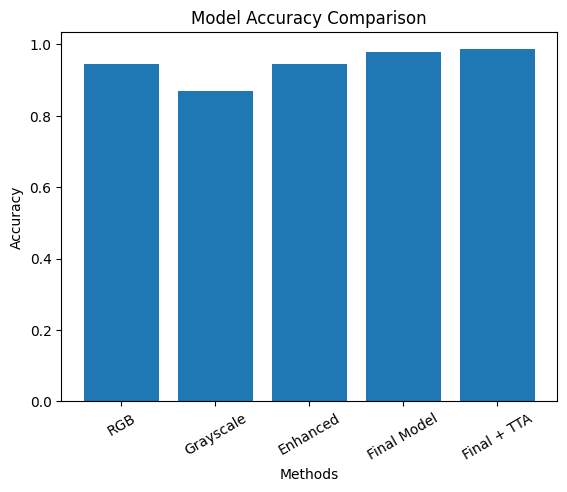

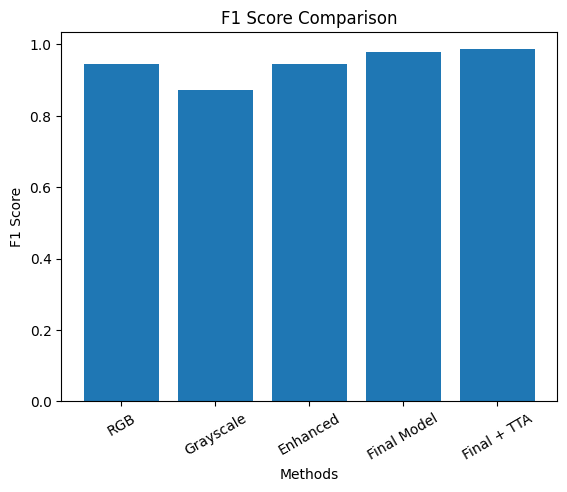

In [26]:
import matplotlib.pyplot as plt

# Your results
methods = ["RGB", "Grayscale", "Enhanced", "Final Model", "Final + TTA"]
accuracy = [0.9454, 0.8698, 0.9449, 0.979, 0.985]  # update if needed
f1_scores = [0.9439, 0.8708, 0.9437, 0.979, 0.985]

# Plot Accuracy
plt.figure()
plt.bar(methods, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Methods")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

# Plot F1 Score
plt.figure()
plt.bar(methods, f1_scores)
plt.title("F1 Score Comparison")
plt.xlabel("Methods")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.show()


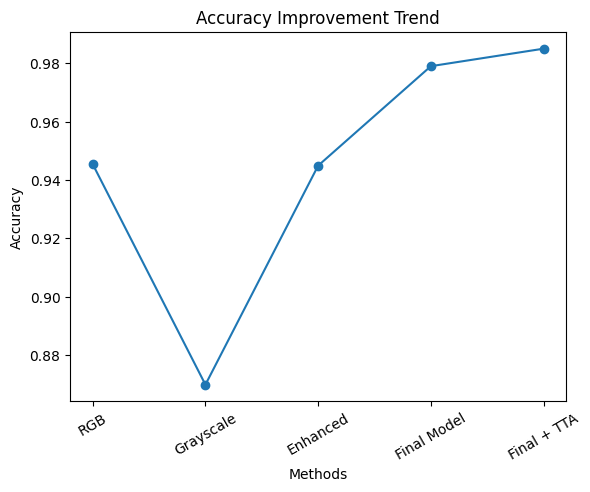

In [27]:
plt.figure()
plt.plot(methods, accuracy, marker='o')
plt.title("Accuracy Improvement Trend")
plt.xlabel("Methods")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [28]:
import torch
torch.save(model.state_dict(), "tomato_model.pth")